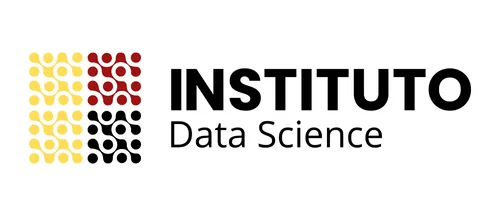 https://institutodatascience.org/

# Aprendizaje Profundo - Clase - Vinos

Este código tiene como objetivo aplicar DL para la clasificación de vinos en dos categorías de calidad (baja o alta calidad) utilizando el conjunto de datos proporcionado.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Cargamos el dataset

In [ ]:
df = pd.read_csv("/content/class_7_wine_dataset_v2.csv")

In [ ]:
len(df)

6497

## Exploramos el dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            6497 non-null   int64  
 1   type                  6497 non-null   object 
 2   fixed acidity         6487 non-null   float64
 3   volatile acidity      6489 non-null   float64
 4   citric acid           6494 non-null   float64
 5   residual sugar        6495 non-null   float64
 6   chlorides             6495 non-null   float64
 7   free sulfur dioxide   6497 non-null   float64
 8   total sulfur dioxide  6497 non-null   float64
 9   density               6497 non-null   float64
 10  pH                    6488 non-null   float64
 11  sulphates             6493 non-null   float64
 12  alcohol               6497 non-null   float64
 13  quality               6497 non-null   int64  
 14  vendor_id             6497 non-null   int64  
dtypes: float64(11), int64

In [ ]:
df.head()

,Unnamed: 0,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,vendor_id
0,0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,369
1,1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,361
2,2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,354
3,3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,325
4,4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,375


In [ ]:
df['type'].unique()

array(['white', 'red'], dtype=object)

In [ ]:
# Type es tipo categórica, transformamos con One Hot Encoding
type_dummies = pd.get_dummies(df['type'], prefix="type")

# Convertir las columnas generadas a uint8
type_dummies = type_dummies.astype('uint8')

# Ver el resultado
type_dummies.head()


,type_red,type_white
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [ ]:
df = pd.concat([df,type_dummies], axis = 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            6497 non-null   int64  
 1   type                  6497 non-null   object 
 2   fixed acidity         6487 non-null   float64
 3   volatile acidity      6489 non-null   float64
 4   citric acid           6494 non-null   float64
 5   residual sugar        6495 non-null   float64
 6   chlorides             6495 non-null   float64
 7   free sulfur dioxide   6497 non-null   float64
 8   total sulfur dioxide  6497 non-null   float64
 9   density               6497 non-null   float64
 10  pH                    6488 non-null   float64
 11  sulphates             6493 non-null   float64
 12  alcohol               6497 non-null   float64
 13  quality               6497 non-null   int64  
 14  vendor_id             6497 non-null   int64  
 15  type_red             

In [ ]:
# Exploramos vendor_id
len(df['vendor_id'].unique())

500

vendor_id es tipo categórica con gran cantidad de valores diferentes, no podemos aplicar One Hot Encoding. Por el momento se descarta, en un futuro utilizaremos capas de embeddings con esta variable.

In [ ]:
# Mi variable a predecir es quality, la calidad del vino.
df['quality'].unique()

array([6, 5, 7, 8, 4, 3, 9])

In [ ]:
import plotly.express as px

quality = df['quality'].to_numpy()

# Crear un DataFrame temporal solo para el gráfico
df_temp = pd.DataFrame(quality, columns=['quality'])

# Crear el gráfico de histograma con Plotly Express
fig = px.histogram(df_temp, x='quality', title='Distribución de la Calidad del Vino')

# Mostrar el gráfico
fig.show()


Por simplicidad convertimos el problema en un problema de clasificación binaria: 0 si el vino es "malo", 1 si el vino es "bueno"

En resumen, este código está creando una etiqueta binaria (0 o 1) en función de la calidad del vino. Si la calidad es 6 o menos, la etiqueta será 0, indicando que el vino no es de alta calidad. Si la calidad es mayor que 6, la etiqueta será 1, indicando que el vino es de alta calidad.

In [ ]:
df["quality_label"] = df["quality"].apply(lambda q:0 if q<=6 else 1)

In [ ]:
df.sample(7)

,Unnamed: 0,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,vendor_id,type_red,type_white,quality_label
3096,3096,white,6.8,0.13,0.39,1.40,0.034,19.0,102.0,0.99121,3.23,0.60,11.3,7,465,0,1,1
2686,2686,white,8.0,0.17,0.29,2.40,0.029,52.0,119.0,0.98944,3.03,0.33,12.9,6,326,0,1,0
1595,1595,white,6.4,0.27,0.49,7.30,0.046,53.0,206.0,0.99560,3.24,0.43,9.2,6,300,0,1,0
10,10,white,8.1,0.27,0.41,1.45,0.033,11.0,63.0,0.99080,2.99,0.56,12.0,5,290,0,1,0
2161,2161,white,6.8,0.37,0.28,4.00,0.030,29.0,79.0,0.99000,3.23,0.46,12.4,7,424,0,1,1
4129,4129,white,6.3,0.34,0.31,6.00,0.020,18.0,68.0,0.98981,3.22,0.29,13.4,7,479,0,1,1
489,489,white,7.4,0.26,0.31,7.60,0.047,52.0,177.0,0.99620,3.13,0.45,8.9,6,315,0,1,0


In [ ]:
# Comprobamos la existencia de nan
df.isna().sum(axis=0)

,0
Unnamed: 0,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0


In [ ]:
# Como tenemos pocos nan, borramos las filas donde hay nan y trabajamos con un dataset completo
ds = df[df.isna().sum(axis = 1) == 0]

In [ ]:
ds.isna().sum()

,0
Unnamed: 0,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0


## Armado del dataset

In [ ]:
# Guardo vendor_id para un futuro modelo con embeddings
vendor_id = ds['vendor_id']
# Recordar que debo borrar del dataset de entrada mi columna de salida!
x = ds.drop(['Unnamed: 0','type','vendor_id','quality','quality_label'], axis=1)
y = ds['quality_label']

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6463 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6463 non-null   float64
 1   volatile acidity      6463 non-null   float64
 2   citric acid           6463 non-null   float64
 3   residual sugar        6463 non-null   float64
 4   chlorides             6463 non-null   float64
 5   free sulfur dioxide   6463 non-null   float64
 6   total sulfur dioxide  6463 non-null   float64
 7   density               6463 non-null   float64
 8   pH                    6463 non-null   float64
 9   sulphates             6463 non-null   float64
 10  alcohol               6463 non-null   float64
 11  type_red              6463 non-null   uint8  
 12  type_white            6463 non-null   uint8  
dtypes: float64(11), uint8(2)
memory usage: 618.5 KB


In [ ]:
y

,quality_label
0,0
1,0
2,0
3,0
4,0
...,...
6491,0
6492,0
6494,0
6495,0


## Normalizacion

Las redes neuronales no requieren que los datos esten normalizados, pero la normalización ayuda a que el algoritmo de gradient descent converga más rápido.

In [ ]:
x = x.to_numpy()
y = y.to_numpy()

In [ ]:
x

array([[ 7.   ,  0.27 ,  0.36 , ...,  8.8  ,  0.   ,  1.   ],
       [ 6.3  ,  0.3  ,  0.34 , ...,  9.5  ,  0.   ,  1.   ],
       [ 8.1  ,  0.28 ,  0.4  , ..., 10.1  ,  0.   ,  1.   ],
       ...,
       [ 6.3  ,  0.51 ,  0.13 , ..., 11.   ,  1.   ,  0.   ],
       [ 5.9  ,  0.645,  0.12 , ..., 10.2  ,  1.   ,  0.   ],
       [ 6.   ,  0.31 ,  0.47 , ..., 11.   ,  1.   ,  0.   ]])

In [ ]:
np.min(x, axis=0)

array([3.8    , 0.08   , 0.     , 0.6    , 0.009  , 1.     , 6.     ,
       0.98711, 2.72   , 0.22   , 8.     , 0.     , 0.     ])

In [ ]:
# Normalización min max
x_norm = (x - np.min(x, axis=0)) / (np.max(x, axis=0 ) - np.min(x, axis=0))

## División del dataset
Divido en entrenamiento y validación

In [ ]:
idx = np.random.permutation(x_norm.shape[0])


In [ ]:
train_idx = idx[0:int(0.85*len(idx))]
valid_idx = idx[int(0.85*len(idx)):]
print(train_idx.shape)
print(valid_idx.shape)

(5493,)
(970,)


In [ ]:
train_x = x_norm[train_idx]
train_y = y[train_idx]
valid_x = x_norm[valid_idx]
valid_y = y[valid_idx]

n_train = train_x.shape[0]
n_valid = valid_x.shape[0]

## Pytorch

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn import metrics

__init__: Se utiliza para inicializar la clase, almacenando las características (x) y las etiquetas (y) del conjunto de datos como variables de clase. Esto es fundamental para acceder a los datos durante la iteración.

__len__: Se define el comportamiento de la función len() aplicada al objeto. Devuelve la longitud del conjunto de datos, que es el número total de muestras.

__getitem__: Define el comportamiento del operador de indexación ([]). Permite acceder a una muestra específica del conjunto de datos mediante su índice (idx). Devuelve las características y la etiqueta correspondiente en esa posición.

En resumen, esta clase MyDataset es esencial para estructurar y organizar los datos de entrada (x) y las etiquetas (y) de manera que puedan ser fácilmente utilizados por PyTorch durante el entrenamiento de modelos de aprendizaje profundo.

In [ ]:
# Pytorch necesita de una clase de dataset que extienda de torch.utils.data.Dataset
# Esta clase dataset debe sobreescribir los métodos init, len y getitem
class MyDataset(Dataset):

  #__init__ guarda el dataset en una variable de clase
  def __init__(self, x, y):
    self.x = x
    self.y = y

  # __len__ define el comportamiento de la función len() sobre el objeto
  def __len__(self):
    return self.x.shape[0]

  # __getitem__ define el comportamiento de los []
  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]

In [ ]:
# Creo el dataset de entrenamiento
train_ds = MyDataset(train_x, train_y)

In [ ]:
# Creo el dataset de validación
valid_ds = MyDataset(valid_x, valid_y)

DataLoader es una herramienta fundamental para manejar grandes conjuntos de datos y realizar entrenamiento por lotes de manera eficiente. Establecer el tamaño del lote y si se deben barajar o no son decisiones importantes dependiendo del problema y del conjunto de datos en cuestión./  shuffle=True baraja los datos antes de dividirlos en lotes.
Es útil para romper cualquier orden específico en los datos que pueda introducir sesgos en el modelo.

In [ ]:
# Pytorch utiliza DataLoader para entregar los dataset de a batches
train_dataloader = DataLoader(train_ds, batch_size = 64, shuffle= True)
valid_dataloader = DataLoader(valid_ds, batch_size=64)



batch_1[1].shape te mostrará las dimensiones del tensor que contiene las etiquetas en el primer lote del conjunto de entrenamiento. Esto es útil para verificar que los lotes se están generando correctamente y para comprender la forma de las etiquetas que se utilizarán durante el entrenamiento del modelo.

In [ ]:
# Test dataloader
batch_1 = next(iter(train_dataloader))
batch_1[1].shape

torch.Size([64])

Tensores
Los objetos torch.Tensor son vectores muy parecidos a los vectores de numpy pero pueden ejecutar funciones en GPU (numpy solo corre en CPU) y pueden guardar información del grafo de cómputos para realizar luego el backpropagation

GPU vs. CPU:

La CPU (Central Processing Unit) es la unidad de procesamiento principal de propósito general.
La GPU (Graphics Processing Unit) está especializada en tareas intensivas de cálculos paralelos, como operaciones matriciales, siendo más eficiente para ciertos tipos de cómputo.
Tensores en GPU:

Los tensores de PyTorch (torch.Tensor) pueden ejecutar operaciones en la GPU para acelerar el procesamiento.
Esto permite realizar cálculos más rápidos en comparación con la CPU, especialmente útil para entrenar modelos de aprendizaje profundo.
Grafo de Cómputos:

Los tensores en PyTorch pueden retener información del grafo de cómputos para habilitar el backpropagation.
Esta característica es esencial para el entrenamiento de modelos de aprendizaje profundo, permitiendo la optimización de parámetros mediante el descenso de gradiente.

### Arquitectura NNet Pytorch
La red neuronal en Pytorch se define extendiendo torch.nn.Module

In [ ]:
# Importación del módulo torch.nn de PyTorch para crear la red neuronal
import torch

# Definición de la clase de la red neuronal que hereda de torch.nn.Module
class NNet(torch.nn.Module):

  # Método de inicialización
  def __init__(self):
    # Llama al constructor de la clase base torch.nn.Module
    super().__init__()
    # Defino la primera capa lineal (densa) con 13 entradas y 200 salidas
    self.linear_1 = torch.nn.Linear(in_features=13, out_features=200, bias=True) #recordemos que bias ayuda a generalizar el aprendizaje
    # Defino la función de activación ReLU para la primera capa
    self.relu_1 = torch.nn.ReLU()
    # Defino la segunda capa lineal (densa) con 200 entradas y 100 salidas
    self.linear_2 = torch.nn.Linear(in_features=200, out_features=100, bias=True)
    # Defino la función de activación ReLU para la segunda capa
    self.relu_2 = torch.nn.ReLU()
    # Defino la capa de salida lineal con 100 entradas y 1 salida
    self.output = torch.nn.Linear(in_features=100, out_features=1, bias=True)

  # Método forward para definir el cálculo del paso hacia adelante
  def forward(self, x):
    # Paso a través de la primera capa lineal
    x = self.linear_1(x)
    # Aplicación de la función de activación ReLU después de la primera capa
    x = self.relu_1(x)
    # Paso a través de la segunda capa lineal
    x = self.linear_2(x)
    # Aplicación de la función de activación ReLU después de la segunda capa
    x = self.relu_2(x)
    # Paso a través de la capa de salida lineal
    x = self.output(x)
    # Retorno del resultado final
    return x


Esta red neuronal es una red completamente conectada o red neuronal densa. Se caracteriza porque cada neurona de una capa está conectada a todas las neuronas de la capa siguiente. Este tipo de red es adecuado para datos tabulares o estructurados y problemas de regresión o clasificación. No es una red recurrente (utilizada para datos secuenciales o temporales) ni una red convolucional (utilizada principalmente para procesamiento de imágenes).

In [ ]:
# Instanciamos la red
nnet = NNet()

In [ ]:
print(nnet)

NNet(
  (linear_1): Linear(in_features=13, out_features=200, bias=True)
  (relu_1): ReLU()
  (linear_2): Linear(in_features=200, out_features=100, bias=True)
  (relu_2): ReLU()
  (output): Linear(in_features=100, out_features=1, bias=True)
)


In [ ]:
# Imprimimos los parámetros optimizables de la red
print([p for p in nnet.parameters()])

[Parameter containing:
tensor([[ 0.1666, -0.1284,  0.0011,  ...,  0.2691, -0.0646,  0.2344],
        [-0.2261,  0.2691,  0.0393,  ..., -0.2438, -0.2393, -0.1955],
        [-0.1667,  0.0282,  0.0820,  ...,  0.1265,  0.0120, -0.0572],
        ...,
        [-0.2755, -0.1286, -0.1678,  ..., -0.2035, -0.1642,  0.0872],
        [ 0.1425,  0.2222,  0.0988,  ...,  0.0577, -0.1994, -0.1483],
        [ 0.2319, -0.1042, -0.2374,  ..., -0.2264,  0.2748,  0.2085]],
       requires_grad=True), Parameter containing:
tensor([ 0.0596,  0.1361, -0.2587, -0.0540,  0.0914,  0.0098, -0.0276, -0.2367,
         0.0487, -0.0347, -0.0114, -0.2115,  0.1729, -0.1073, -0.1196, -0.1208,
         0.2189, -0.1694,  0.2659,  0.1120, -0.0352,  0.2313, -0.0404, -0.1353,
         0.0226, -0.1484, -0.0510, -0.1962, -0.0772,  0.1072, -0.0654, -0.2298,
        -0.1099, -0.1942, -0.0568,  0.2095, -0.0759,  0.0245,  0.2532, -0.0895,
        -0.1847,  0.1629,  0.2343, -0.1780, -0.0923, -0.1819, -0.0751,  0.2548,
         0.06

In [ ]:
# Imprimo la cantidad de parámetros optimizables de la red
print(sum(p.numel() for p in nnet.parameters()))

23001



La expresión p.numel() devuelve el número de elementos en el tensor p. En el contexto de este código, p representa cada parámetro de la red neuronal (nnet). La función numel() cuenta el número total de elementos en un tensor, que es la multiplicación de sus dimensiones.

Por lo tanto, sum(p.numel() for p in nnet.parameters()) está calculando la suma total de todos los parámetros de la red neuronal. Esta suma es una medida de la complejidad del modelo y la cantidad de parámetros que el optimizador debe ajustar durante el entrenamiento para minimizar la función de pérdida.

### Loss y optimizador
- Como loss function utilizo BCE Binary Cross Entropy por ser un problema de clasificación binaria.

**Nota**: la función sigmoid de salida no se definió en la arquitectura de la red neuronal porque utilizo BCEWithLogitsLoss que combina sigmoid+BCE. Hago esto para tener mejor estabilidad numérica: [link](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html).

Podría utilizar BCELoss y agregar la capa sigmoid en la clase NNet

- Como optimizador utilizo Adam

Un valor de lr=0.01 para la tasa de aprendizaje indica que durante cada paso de entrenamiento, los pesos del modelo se ajustan multiplicándolos por 0.01, controlando la magnitud de las actualizaciones. Este valor se selecciona empíricamente para equilibrar la convergencia eficiente y evitar divergencias en el proceso de optimización. La elección de la tasa de aprendizaje es crítica para el rendimiento del modelo y requiere ajuste cuidadoso. / recordar que sum indica que las pérdidas de todos los elementos se suman para obtener un solo valor de pérdida, lo cual es útil cuando se necesita calcular la pérdida total en lugar de la media.

In [ ]:
# Definición de la función de pérdida con reducción por suma
loss_function = torch.nn.BCEWithLogitsLoss(reduction='sum')

# Definición del optimizador Adam con una tasa de aprendizaje de 0.01
optimizer = torch.optim.Adam(nnet.parameters(), lr=0.01)

Pytorch puede correr en GPU. Con el siguiente código chequeo si hay una GPU compatible disponible y la utilizo en ese caso.

**Como utilizar GPU con colab**: Ir a Entorno de ejecucion -> Cambiar tipo de entorno de ejecución. Seleccionar GPU

In [ ]:
device = "cpu"
if torch.cuda.is_available():
  device = "cuda:0"

device

'cuda:0'

In [ ]:
# Copio la red neuronal al dispositivo donde entrene la red neuronal
nnet = nnet.to(device)

### Entrenamiento y validación red neuronal

Entreno con algoritmo Mini-Batch

# New Section

In [ ]:
# Algoritmo Mini-batch

# cantidad de epochs
epochs = 100 # Número total de épocas para el entrenamiento

# Listas para almacenar la pérdida por época para entrenamiento y validación
train_loss_by_epoch = []
valid_loss_by_epoch = []

# Doble loop algoritmo Mini-Batch
for epoch in range(epochs):  # Bucle principal que itera a través de cada época

  ############################################
  ## Entrenamiento
  ############################################
  nnet.train(True)  # Pone la red en modo entrenamiento

  epoch_loss = 0  # Inicializa la pérdida de la época
  epoch_y_hat = []  # Lista para almacenar las predicciones de la época
  epoch_y = []  # Lista para almacenar los valores reales de la época

  for i, data in enumerate(train_dataloader):  # Bucle interno que itera a través de cada mini-batch de entrenamiento
    # Obtengo los datos del batch de entrenamiento
    x_batch, y_batch = data  # Desempaqueta las características y las etiquetas del batch
    # Copio el batch al dispositivo donde entreno la red neuronal
    x_batch = x_batch.to(device).float()  # Mueve las características al dispositivo y las convierte a float
    y_batch = y_batch.to(device).float().reshape(-1, 1)  # Mueve las etiquetas al dispositivo, las convierte a float y les da forma

    # Paso forward
    # Limpio optimizer para empezar un nuevo cálculo de gradiente
    optimizer.zero_grad()  # Resetea los gradientes del optimizador a cero
    nnet_output = nnet(x_batch)  # Calcula la salida de la red para el batch
    y_batch_hat = torch.sigmoid(nnet_output)  # Aplica la función sigmoide a la salida de la red

    # Calculo el loss
    loss = loss_function(nnet_output, y_batch)  # Calcula la pérdida entre la salida de la red y las etiquetas verdaderas

    # Backpropagation
    loss.backward()  # Calcula los gradientes mediante retropropagación

    # Actualizar los parámetros
    optimizer.step()  # Actualiza los parámetros de la red usando los gradientes calculados

    # Almaceno los valores reales y mis predicciones para cálcular las métricas
    epoch_y += list(y_batch.detach().cpu().numpy())  # Almacena las etiquetas verdaderas del batch
    epoch_y_hat += list(y_batch_hat.detach().cpu().numpy())  # Almacena las predicciones del batch
    # Acumulo la loss del batch
    epoch_loss = epoch_loss + loss.item()  # Suma la pérdida del batch a la pérdida total de la época

  # Calculo la media de la loss
  epoch_loss = epoch_loss / n_train  # Calcula la pérdida media de la época
  # Almaceno la loss de la epoch para graficar
  train_loss_by_epoch.append(epoch_loss)  # Almacena la pérdida media de la época
  # Cálculo la métrica de la epoch
  accuracy = metrics.accuracy_score(epoch_y, [j >= 0.5 for j in epoch_y_hat])  # Calcula la precisión de las predicciones de la época
  # recordemos que la clasificacion es binaria Para convertir las probabilidades
  #en predicciones binarias (0 o 1), se usa un umbral. El umbral más común es 0.5.
  ############################################
  ## Validación
  ############################################
  # Desactivo el cálculo de gradiente para validación
  #para Evaluar el modelo correctamente sin influencias del proceso de entrenamiento.
  nnet.train(False)  # Pone la red en modo evaluación (sin cálculo de gradientes)

  valid_epoch_loss = 0  # Inicializa la pérdida de validación de la época
  valid_epoch_y_hat = []  # Lista para almacenar las predicciones de validación de la época
  valid_epoch_y = []  # Lista para almacenar los valores reales de validación de la época

  for i, data in enumerate(valid_dataloader):  # Bucle interno que itera a través de cada mini-batch de validación
    # Obtengo los datos del batch de validación
    x_batch, y_batch = data  # Desempaqueta las características y las etiquetas del batch
    # Copio el batch al dispositivo donde entreno la red neuronal
    x_batch = x_batch.to(device).float()  # Mueve las características al dispositivo y las convierte a float
    y_batch = y_batch.to(device).float().reshape(-1, 1)  # Mueve las etiquetas al dispositivo, las convierte a float y les da forma

    # Paso forward
    nnet_output = nnet(x_batch)  # Calcula la salida de la red para el batch de validación
    y_batch_hat = torch.sigmoid(nnet_output)  # Aplica la función sigmoide a la salida de la red

    # Calculo el loss
    loss = loss_function(nnet_output, y_batch)  # Calcula la pérdida entre la salida de la red y las etiquetas verdaderas

    # En validación no hago backpropagation!!

    # Almaceno los valores reales y mis predicciones para cálcular las métricas
    valid_epoch_y += list(y_batch.detach().cpu().numpy())  # Almacena las etiquetas verdaderas del batch
    valid_epoch_y_hat += list(y_batch_hat.detach().cpu().numpy())  # Almacena las predicciones del batch
    # Acumulo la loss del batch
    valid_epoch_loss = valid_epoch_loss + loss.item()  # Suma la pérdida del batch a la pérdida total de validación de la época

  # Calculo la media de la loss
  valid_epoch_loss = valid_epoch_loss / n_valid  # Calcula la pérdida media de validación de la época
  # Almaceno la loss de la epoch para graficar
  valid_loss_by_epoch.append(valid_epoch_loss)  # Almacena la pérdida media de validación de la época
  # Cálculo la métrica de la epoch
  valid_accuracy = metrics.accuracy_score(valid_epoch_y, [j >= 0.5 for j in valid_epoch_y_hat])  # Calcula la precisión de las predicciones de validación de la época

  ############################################
  ## Impresión de resultados por epoch
  ############################################
  print(f" Epoch {epoch} | " \
        f"Train/Valid loss: {epoch_loss:.3f} / {valid_epoch_loss:.3f} | " \
        f"Train/Valid accuracy: {accuracy:.3f} / {valid_accuracy:.3f}")  # Imprime la pérdida y la precisión de entrenamiento y validación para la época actual


 Epoch 0 | Train/Valid loss: 0.452 / 0.363 | Train/Valid accuracy: 0.799 / 0.837
 Epoch 1 | Train/Valid loss: 0.406 / 0.357 | Train/Valid accuracy: 0.811 / 0.843
 Epoch 2 | Train/Valid loss: 0.403 / 0.352 | Train/Valid accuracy: 0.818 / 0.847
 Epoch 3 | Train/Valid loss: 0.393 / 0.358 | Train/Valid accuracy: 0.815 / 0.842
 Epoch 4 | Train/Valid loss: 0.388 / 0.363 | Train/Valid accuracy: 0.817 / 0.838
 Epoch 5 | Train/Valid loss: 0.384 / 0.339 | Train/Valid accuracy: 0.822 / 0.846
 Epoch 6 | Train/Valid loss: 0.380 / 0.336 | Train/Valid accuracy: 0.819 / 0.844
 Epoch 7 | Train/Valid loss: 0.377 / 0.338 | Train/Valid accuracy: 0.823 / 0.849
 Epoch 8 | Train/Valid loss: 0.376 / 0.353 | Train/Valid accuracy: 0.822 / 0.824
 Epoch 9 | Train/Valid loss: 0.380 / 0.342 | Train/Valid accuracy: 0.818 / 0.845
 Epoch 10 | Train/Valid loss: 0.379 / 0.340 | Train/Valid accuracy: 0.822 / 0.834
 Epoch 11 | Train/Valid loss: 0.375 / 0.364 | Train/Valid accuracy: 0.822 / 0.826
 Epoch 12 | Train/Valid lo

Text(0, 0.5, 'BCE')

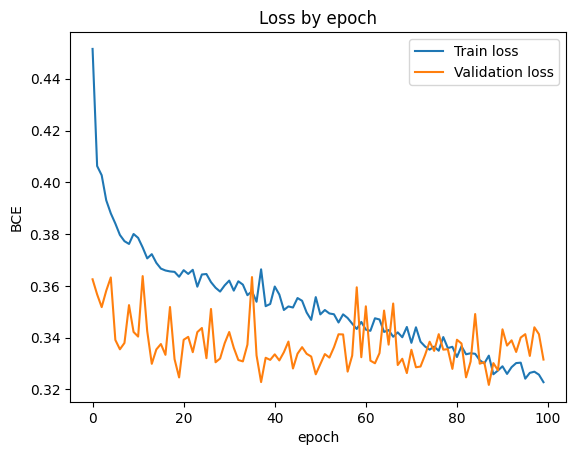

In [ ]:
fig, ax1= plt.subplots(1,1)
ax1.plot(train_loss_by_epoch, label="Train loss")
ax1.plot(valid_loss_by_epoch, label="Validation loss")
ax1.legend()
ax1.set_title("Loss by epoch")
ax1.set_xlabel("epoch")
ax1.set_ylabel("BCE")

In [ ]:
# Utilizamos el último modelo entrenado con PyTorch para predecir en el conjunto de validación
nnet.train(False)  # Aseguramos que el modelo está en modo de evaluación
pytorch_outputs = nnet(torch.tensor(valid_x, dtype=torch.float32).to(device))
pytorch_predictions = torch.sigmoid(pytorch_outputs).cpu().detach().numpy().squeeze()
pytorch_predictions_binary = [1 if p >= 0.5 else 0 for p in pytorch_predictions]
pytorch_accuracy = metrics.accuracy_score(valid_y, pytorch_predictions_binary)

print(f"Accuracy of PyTorch Deep Neural Network on Validation Set: {pytorch_accuracy:.3f}")


Accuracy of PyTorch Deep Neural Network on Validation Set: 0.862


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Imprimir métricas para el modelo PyTorch
print("\nMetrics for PyTorch Deep Neural Network:")
print(f"Confusion Matrix:\n{confusion_matrix(valid_y, pytorch_predictions_binary)}")
print(f"Classification Report:\n{classification_report(valid_y, pytorch_predictions_binary)}")



Metrics for PyTorch Deep Neural Network:
Confusion Matrix:
[[778  36]
 [ 98  58]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       814
           1       0.62      0.37      0.46       156

    accuracy                           0.86       970
   macro avg       0.75      0.66      0.69       970
weighted avg       0.84      0.86      0.85       970



In [ ]:
# Supongamos que tienes 970 predicciones de validación (como en el informe de clasificación)
n_predictions = 970

# Porcentaje de predicciones correctas (accuracy)
accuracy = 0.836

# Predicciones correctas e incorrectas
correct_predictions = accuracy * n_predictions
incorrect_predictions = n_predictions - correct_predictions

# Supongamos que cada predicción incorrecta cuesta $30 y cada predicción correcta ahorra $50
cost_per_incorrect = 30
benefit_per_correct = 50

# Calcular el impacto económico
total_cost = incorrect_predictions * cost_per_incorrect
total_benefit = correct_predictions * benefit_per_correct

# Impacto económico neto
net_impact = total_benefit - total_cost

print(f"Total cost of incorrect predictions: ${total_cost:.2f}")
print(f"Total benefit of correct predictions: ${total_benefit:.2f}")
print(f"Net economic impact: ${net_impact:.2f}")


Total cost of incorrect predictions: $4772.40
Total benefit of correct predictions: $40546.00
Net economic impact: $35773.60


Áreas de Mejora: Aunque el impacto neto es positivo, el análisis también destaca el costo de las predicciones incorrectas. La empresa podría explorar formas de mejorar el modelo para reducir estos costos y aumentar aún más el beneficio neto.